In [70]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import statsmodels.formula.api as smf
import statsmodels.api as sm
import joblib
from math import ceil
from scipy import stats
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score, accuracy_score, classification_report
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
print("Library imports successful")

Library imports successful


https://www.kaggle.com/datasets/START-UMD/gtd

In [71]:
df = pd.read_csv('../data/globalterrorismdb_0718dist.csv')
df = df.copy()
df.sample(10, random_state=42)
# Random_state -- save time for running the code again

C:\Users\hungh\AppData\Local\Temp\ipykernel_27052\226401783.py:1: DtypeWarning: Columns (4,6,31,33,61,62,63,76,79,90,92,94,96,114,115,121) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('../data/globalterrorismdb_0718dist.csv')


,eventid,iyear,imonth,iday,approxdate,extended,resolution,country,country_txt,region,...,addnotes,scite1,scite2,scite3,dbsource,INT_LOG,INT_IDEO,INT_MISC,INT_ANY,related
83552,200706120042,2007,6,12,NaN,0,NaN,153,Pakistan,6,...,NaN,"�Student leader gunned down in Karachi,� Pakis...",�Selection list: Pakistan press Nawa-e Waqt 14...,�Selection list: Pakistan press Ummat 14 Jun 0...,CETIS,-9,-9,0,-9,NaN
30191,198702160006,1987,2,16,NaN,0,NaN,45,Colombia,3,...,NaN,NaN,NaN,NaN,PGIS,0,0,0,0,NaN
51303,199205060002,1992,5,6,NaN,0,NaN,92,India,6,...,NaN,NaN,NaN,NaN,PGIS,-9,-9,1,1,NaN
73581,200201030001,2002,1,3,NaN,0,NaN,167,Russia,9,...,NaN,�At least 6 civilians reported killed in Chech...,NaN,NaN,CETIS,0,0,0,0,"200201030001, 200201030002, 200201030003"
17703,198212310013,1982,12,31,NaN,0,NaN,69,France,8,...,NaN,NaN,NaN,NaN,PGIS,0,0,0,0,NaN
174077,201704200007,2017,4,20,NaN,0,NaN,182,Somalia,11,...,NaN,"""Somalia: Roadside Bomb Hits AU Military Convo...","""Program Summary: Radio Andalus in Somali 1030...",NaN,START Primary Collection,0,1,1,1,NaN
132395,201405240203,2014,5,24,NaN,1,NaN,195,Sudan,11,...,NaN,"""Peacekeepers in North Darfur's Kabkabiya 'Sho...",NaN,NaN,START Primary Collection,0,0,0,0,"201405240202, 201405240203, 201405240204"
12791,198102010004,1981,2,1,NaN,0,NaN,83,Guatemala,2,...,NaN,NaN,NaN,NaN,PGIS,-9,-9,0,-9,NaN
154258,201510150035,2015,10,15,2015-10-15 00:00:00,0,NaN,92,India,6,...,NaN,"""Maoist arrested in Latehar district, arms sei...",NaN,NaN,START Primary Collection,-9,-9,0,-9,NaN
28720,198607230002,1986,7,23,NaN,0,NaN,45,Colombia,3,...,NaN,NaN,NaN,NaN,PGIS,0,0,0,0,NaN


In [72]:
print(df.shape)

(181691, 135)


In [73]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 181691 entries, 0 to 181690
Columns: 135 entries, eventid to related
dtypes: float64(55), int64(22), object(58)
memory usage: 187.1+ MB


In [74]:
df.sample(10)

,eventid,iyear,imonth,iday,approxdate,extended,resolution,country,country_txt,region,...,addnotes,scite1,scite2,scite3,dbsource,INT_LOG,INT_IDEO,INT_MISC,INT_ANY,related
42331,199004300008,1990,4,30,NaN,0,NaN,11,Argentina,3,...,NaN,NaN,NaN,NaN,PGIS,0,1,1,1,NaN
139461,201410220027,2014,10,22,NaN,1,NaN,113,Libya,10,...,NaN,"""Four Tripoli kidnappings and Egyptian embassy...","""SOCAFRICA: Libya Incident Tracker: 18 � 24 Oc...",NaN,START Primary Collection,-9,-9,1,1,"201410220027, 201410220028, 201410220029, 2014..."
110899,201209110023,2012,9,11,NaN,0,NaN,228,Yemen,10,...,NaN,"""Gunmen kill 2 Yemeni soldiers in checkp...",NaN,NaN,START Primary Collection,-9,-9,0,-9,NaN
160884,201604060037,2016,4,5,NaN,0,NaN,4,Afghanistan,6,...,NaN,"""Civilian killed, eight injured separately,"" F...",NaN,NaN,START Primary Collection,0,0,0,0,NaN
134671,201407100013,2014,7,10,NaN,0,NaN,182,Somalia,11,...,NaN,"""Somalia: Al-Shabaab Militants Kill 2 in South...","""SOCAFRICA: Al-Shabaab (AS) Incident Tracker: ...",NaN,START Primary Collection,0,0,0,0,NaN
149065,201506070001,2015,6,7,2015-06-07 00:00:00,0,NaN,95,Iraq,10,...,NaN,"""Iraq: Roundup of Security Incidents 02-08 Jun...",NaN,NaN,START Primary Collection,-9,-9,0,-9,NaN
180265,201711070007,2017,11,7,NaN,0,NaN,95,Iraq,10,...,NaN,"""Iraq: Roundup of Violent Activities Targeting...","""Iraq: Security Roundup 1900 GMT 7 November 20...",NaN,START Primary Collection,-9,-9,0,-9,NaN
3788,197605060003,1976,5,6,NaN,0,NaN,98,Italy,8,...,NaN,NaN,NaN,NaN,PGIS,-9,-9,0,-9,NaN
143892,201502030037,2015,2,1,NaN,0,NaN,60,Egypt,10,...,NaN,"""Unknown militants explode gas pipeline in...","""Selection List: Egyptian Islamist Opposition ...",NaN,START Primary Collection,-9,-9,0,-9,NaN
81214,200608010030,2006,8,1,NaN,0,NaN,95,Iraq,10,...,NaN,"Deutsche Presse-Agentur, �At least 49 killed i...","Ammar Karim, �Bombers blitz Iraqi forces, more...","Xinhua General News Service, �Suicide car bomb...",CETIS,-9,-9,0,-9,NaN


In [75]:
df = df.drop_duplicates()


In [76]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 181691 entries, 0 to 181690
Columns: 135 entries, eventid to related
dtypes: float64(55), int64(22), object(58)
memory usage: 187.1+ MB


In [77]:
df.describe()

,eventid,iyear,imonth,iday,extended,country,region,latitude,longitude,specificity,...,ransomamt,ransomamtus,ransompaid,ransompaidus,hostkidoutcome,nreleased,INT_LOG,INT_IDEO,INT_MISC,INT_ANY
count,1.816910e+05,181691.000000,181691.000000,181691.000000,181691.000000,181691.000000,181691.000000,177135.000000,1.771340e+05,181685.000000,...,1.350000e+03,5.630000e+02,7.740000e+02,552.000000,10991.000000,10400.000000,181691.000000,181691.000000,181691.000000,181691.000000
mean,2.002705e+11,2002.638997,6.467277,15.505644,0.045346,131.968501,7.160938,23.498343,-4.586957e+02,1.451452,...,3.172530e+06,5.784865e+05,7.179437e+05,240.378623,4.629242,-29.018269,-4.543731,-4.464398,0.090010,-3.945952
std,1.325957e+09,13.259430,3.388303,8.814045,0.208063,112.414535,2.933408,18.569242,2.047790e+05,0.995430,...,3.021157e+07,7.077924e+06,1.014392e+07,2940.967293,2.035360,65.720119,4.543547,4.637152,0.568457,4.691325
min,1.970000e+11,1970.000000,0.000000,0.000000,0.000000,4.000000,1.000000,-53.154613,-8.618590e+07,1.000000,...,-9.900000e+01,-9.900000e+01,-9.900000e+01,-99.000000,1.000000,-99.000000,-9.000000,-9.000000,-9.000000,-9.000000
25%,1.991021e+11,1991.000000,4.000000,8.000000,0.000000,78.000000,5.000000,11.510046,4.545640e+00,1.000000,...,0.000000e+00,0.000000e+00,-9.900000e+01,0.000000,2.000000,-99.000000,-9.000000,-9.000000,0.000000,-9.000000
50%,2.009022e+11,2009.000000,6.000000,15.000000,0.000000,98.000000,6.000000,31.467463,4.324651e+01,1.000000,...,1.500000e+04,0.000000e+00,0.000000e+00,0.000000,4.000000,0.000000,-9.000000,-9.000000,0.000000,0.000000
75%,2.014081e+11,2014.000000,9.000000,23.000000,0.000000,160.000000,10.000000,34.685087,6.871033e+01,1.000000,...,4.000000e+05,0.000000e+00,1.273412e+03,0.000000,7.000000,1.000000,0.000000,0.000000,0.000000,0.000000
max,2.017123e+11,2017.000000,12.000000,31.000000,1.000000,1004.000000,12.000000,74.633553,1.793667e+02,5.000000,...,1.000000e+09,1.320000e+08,2.750000e+08,48000.000000,7.000000,2769.000000,1.000000,1.000000,1.000000,1.000000


In [78]:
df.isnull().sum()[df.isnull().sum() > 0].sort_values(ascending=False)

gsubname3           181671
weapsubtype4_txt    181621
weapsubtype4        181621
weaptype4_txt       181618
weaptype4           181618
                     ...  
guncertain1            380
ishostkid              178
specificity              6
multiple                 1
doubtterr                1
Length: 106, dtype: int64

In [79]:
df.dtypes.value_counts()

object     58
float64    55
int64      22
Name: count, dtype: int64

### EDA -> Data Visualuzation before applying ML models
    Data Cleaning

In [80]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
print(df[num_cols].dtypes.count())

cat_cols = df.select_dtypes(include=['object']).columns.tolist()
print(df[cat_cols].dtypes.count())


77
58


In [81]:
num_cols

['eventid',
 'iyear',
 'imonth',
 'iday',
 'extended',
 'country',
 'region',
 'latitude',
 'longitude',
 'specificity',
 'vicinity',
 'crit1',
 'crit2',
 'crit3',
 'doubtterr',
 'alternative',
 'multiple',
 'success',
 'suicide',
 'attacktype1',
 'attacktype2',
 'attacktype3',
 'targtype1',
 'targsubtype1',
 'natlty1',
 'targtype2',
 'targsubtype2',
 'natlty2',
 'targtype3',
 'targsubtype3',
 'natlty3',
 'guncertain1',
 'guncertain2',
 'guncertain3',
 'individual',
 'nperps',
 'nperpcap',
 'claimed',
 'claimmode',
 'claim2',
 'claimmode2',
 'claim3',
 'claimmode3',
 'compclaim',
 'weaptype1',
 'weapsubtype1',
 'weaptype2',
 'weapsubtype2',
 'weaptype3',
 'weapsubtype3',
 'weaptype4',
 'weapsubtype4',
 'nkill',
 'nkillus',
 'nkillter',
 'nwound',
 'nwoundus',
 'nwoundte',
 'property',
 'propextent',
 'propvalue',
 'ishostkid',
 'nhostkid',
 'nhostkidus',
 'nhours',
 'ndays',
 'ransom',
 'ransomamt',
 'ransomamtus',
 'ransompaid',
 'ransompaidus',
 'hostkidoutcome',
 'nreleased',
 'INT_

In [82]:
cat_cols

['approxdate',
 'resolution',
 'country_txt',
 'region_txt',
 'provstate',
 'city',
 'location',
 'summary',
 'alternative_txt',
 'attacktype1_txt',
 'attacktype2_txt',
 'attacktype3_txt',
 'targtype1_txt',
 'targsubtype1_txt',
 'corp1',
 'target1',
 'natlty1_txt',
 'targtype2_txt',
 'targsubtype2_txt',
 'corp2',
 'target2',
 'natlty2_txt',
 'targtype3_txt',
 'targsubtype3_txt',
 'corp3',
 'target3',
 'natlty3_txt',
 'gname',
 'gsubname',
 'gname2',
 'gsubname2',
 'gname3',
 'gsubname3',
 'motive',
 'claimmode_txt',
 'claimmode2_txt',
 'claimmode3_txt',
 'weaptype1_txt',
 'weapsubtype1_txt',
 'weaptype2_txt',
 'weapsubtype2_txt',
 'weaptype3_txt',
 'weapsubtype3_txt',
 'weaptype4_txt',
 'weapsubtype4_txt',
 'weapdetail',
 'propextent_txt',
 'propcomment',
 'divert',
 'kidhijcountry',
 'ransomnote',
 'hostkidoutcome_txt',
 'addnotes',
 'scite1',
 'scite2',
 'scite3',
 'dbsource',
 'related']

#### National Security Strategy (NSS) and the National Defense Strategy (NDS) .
    China
    Russia
    Iran
    North Korea
    Terrorist groups (like ISIS and al-Qaeda)

Zone in US-affected -> industry,Target(s)

#### Important fields
    country_txt - This field identifies the country or location where the incident occurred.
    region_txt -This field identifies the region in which the incident occurred.
    city - Name of the city, village, or town in which the incident occurred

    targtype1_txt - The general type of target/victim
    targsubtype1_txt - The more specific target category
    target1 -The specific person, building, installation that was targeted and/or victimized
    weaptype1_txt 


<Axes: ylabel='region_txt'>

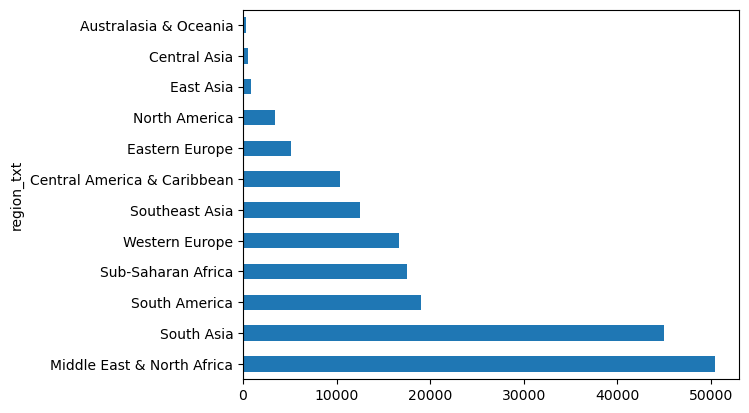

In [83]:
incidents_per_region = df.groupby('region_txt').size().sort_values(ascending=False)
incidents_per_region.plot(kind='barh')

In [84]:
targets = df['target1'].value_counts()
targets.to_csv('../data/target_counts.csv')

In [85]:
military = [
    "soldiers", "soldier",
    "military unit", "unit",
    "military base", "base",
    "post", "outpost",
    "camp"
]

In [86]:
military_flag = (
    df["target1"].str.lower().isin(military)
).astype(int)

In [87]:
df['target'] = df['target1'].map(lambda x: 'military' if str(x).lower() in military else 'other')

In [88]:
df['target'].sample(20)

162276    other
177010    other
137979    other
129076    other
138024    other
116944    other
128417    other
88305     other
175415    other
99111     other
51047     other
179823    other
136341    other
179008    other
77279     other
147560    other
125120    other
142244    other
44317     other
15717     other
Name: target, dtype: object

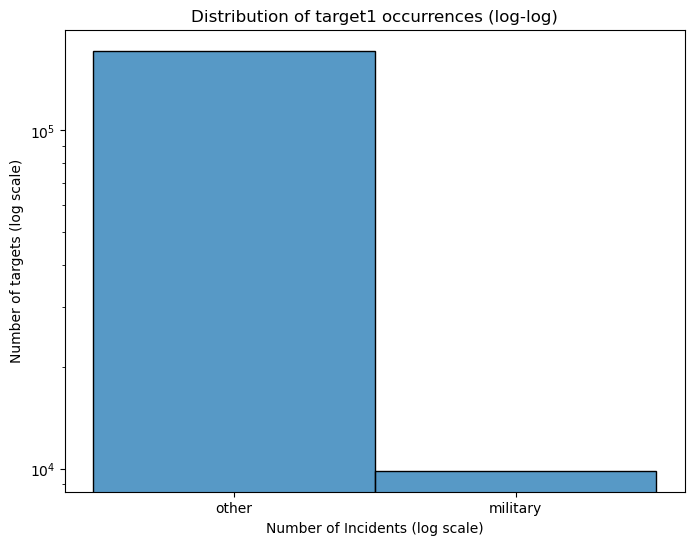

In [89]:
fig, ax = plt.subplots(figsize=(8,6))
sns.histplot(df['target'], bins=30, log=True)
plt.xlabel('Number of Incidents (log scale)')
plt.ylabel('Number of targets (log scale)')
plt.title('Distribution of target1 occurrences (log-log)')
plt.show()

In [90]:
north_america = df[df['region_txt'] == 'North America']
north_america.shape

(3456, 136)

In [91]:
df.isnull().sum().sort_values(ascending=False)

gsubname3           181671
weapsubtype4_txt    181621
weapsubtype4        181621
weaptype4           181618
weaptype4_txt       181618
                     ...  
dbsource                 0
INT_IDEO                 0
INT_MISC                 0
INT_ANY                  0
target                   0
Length: 136, dtype: int64

In [92]:
# Clean target1 missing values
df = df.dropna(subset=['target1'])

In [93]:

# 3. Create X, y AFTER cleaning
X = df[['extended', 'region_txt','country_txt', 'target' , 'weaptype1_txt','gname', 'nkill', 'nwound']]
y = df['success']
print(X.shape, y.shape)

(181053, 8) (181053,)


In [94]:
# 4. Train-test split
X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42)

In [95]:
# 5. Identify numeric vs categorical columns
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()


In [96]:
# 6. Transform pipelines
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler())
])

In [97]:
categorical_transformer = Pipeline(steps=[
    # ("imputer", SimpleImputer(strategy="constant", fill_value='military_flag')),
    ("onehot", OneHotEncoder(sparse_output=False, handle_unknown="ignore"))
])


In [98]:
# 7. Column transformer
preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])


In [99]:
#8. Lingrear Regression model pipeline
log_reg_model = Pipeline([
    ('preprocess', preprocessor),
    ('model', LogisticRegression())
])

# 9. Fit model
log_reg_model.fit(X_train, y_train)
log_score = log_reg_model.score(X_test, y_test)
print(f"Linear Regression Score: {log_score:.4f}")
print("Linear Regression Accurary", log_score *100)


Linear Regression Score: 0.8943
Linear Regression Accurary 89.42586506862555


In [100]:
 # 8. Random Forest Classifier model pipeline
randm_for_class_model = Pipeline([
    ('preprocess', preprocessor),
    ('model', RandomForestClassifier(n_estimators=100))
    ])

# 9. Fit model
randm_for_class_model.fit(X_train, y_train)
score = randm_for_class_model.score(X_test, y_test)
print(f"Random Forest R^2 Score: {score:.4f}")
print("Random Forest Accuracy:", score *100)

Random Forest R^2 Score: 0.8955
Random Forest Accuracy: 89.55289829057469


In [101]:
param_grid = {
    "model__n_estimators": [50, 100],
    "model__max_depth": [5, None],
    "model__max_features": ["sqrt", "log2", 0.8],
    "model__min_samples_split": [2, 5, 10],
}

grid_search = GridSearchCV(
    estimator=randm_for_class_model,
    param_grid=param_grid,
    cv=5,
    scoring="precision",
    n_jobs=-1,
    verbose=2
)

In [102]:
# 4. Fit
grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Fitting 5 folds for each of 36 candidates, totalling 180 fits


c:\Users\hungh\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py:528: FitFailedWarning: 
173 fits failed out of a total of 180.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
3 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\hungh\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\hungh\anaconda3\Lib\site-packages\sklearn\base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "c:\Users\hungh\anaconda3\Lib\site-packages\sklearn\pipeline.py", line 654, in fit
    Xt = self._fit(X, y, rou


Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00      3868
           1       0.89      1.00      0.94     32343

    accuracy                           0.89     36211
   macro avg       0.45      0.50      0.47     36211
weighted avg       0.80      0.89      0.84     36211



c:\Users\hungh\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\hungh\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\hungh\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [103]:

# 5. Results
print("Best params:", grid_search.best_params_)
print("Best CV score:", grid_search.best_score_)

# 6. Final test score
best_model = grid_search.best_estimator_
test_score = best_model.score(X_test, y_test)
print("Test Precision:", test_score)

Best params: {'model__max_depth': 5, 'model__max_features': 'sqrt', 'model__min_samples_split': 2, 'model__n_estimators': 50}
Best CV score: nan
Test Precision: 0.8931816298914694
